# Laboratorio 3: Generación de variables aleatorias continuas

**Estudiante:** J. Gregorio Delgado  
**Código:** 160005010  
**Curso:** Simulación Computacional — Universidad de los Llanos


## 3. Generador pseudoaleatorio base

Se usa el generador congruencial mixto $X_{n+1}=(aX_n+c)\bmod m$, con $m=2^{32}$, $a=1664525$ y $c=1013904223$. Cumple las condiciones de Hull–Dobell: $c$ es coprimo con $m$, $a-1$ es divisible por el único factor primo de $m$ (2) y también por 4. Por tanto, para cualquier semilla, alcanza período completo $m$. Los uniformes se toman como $U_n=(X_n+0.5)/m$, evitando exactamente 0 y 1.

In [16]:
from pathlib import Path
import math
import numpy as np
from PIL import Image, ImageDraw, ImageFont

IMG_DIR = Path('imagenes')
IMG_DIR.mkdir(exist_ok=True)

class LCG:
    def __init__(self, seed, a=1664525, c=1013904223, m=2**32):
        if not 0 <= seed < m:
            raise ValueError('La semilla debe pertenecer a [0, m).')
        self.state, self.a, self.c, self.m = seed, a, c, m

    def random(self):
        self.state = (self.a * self.state + self.c) % self.m
        return (self.state + 0.5) / self.m

    def sample(self, n):
        return np.fromiter((self.random() for _ in range(n)), dtype=float, count=n)

# Verificación computacional de las condiciones de período completo.
a, c, m = 1664525, 1013904223, 2**32
assert math.gcd(c, m) == 1 and (a - 1) % 2 == 0 and (a - 1) % 4 == 0
prueba_u = LCG(160005010).sample(1000)
print(f'Uniformes de prueba: media={prueba_u.mean():.4f}, varianza={prueba_u.var(ddof=1):.4f}')
print('Valores esperados aproximados: media=0.5, varianza=1/12=0.0833')

Uniformes de prueba: media=0.5100, varianza=0.0844
Valores esperados aproximados: media=0.5, varianza=1/12=0.0833


## 5.1. Generación de variables aleatorias continuas

En los cuatro ejercicios se aplica transformada inversa. Para el inciso b, la CDF se invierte por tramos. En Weibull se fijan $\alpha=1.5$ y $\beta=2$ porque la guía no da valores; ambos quedan como argumentos modificables.

In [17]:
N = 1000

def muestra_a(n=N, seed=101):
    u = LCG(seed).sample(n)
    return np.log1p((math.e - 1) * u)

def muestra_b(n=N, seed=202):
    u = LCG(seed).sample(n)
    return np.where(u <= 0.25, 2 + 2*np.sqrt(u), 6 - np.sqrt(12*(1-u)))

def muestra_c(n=N, seed=303):
    u = LCG(seed).sample(n)
    return (-1 + np.sqrt(1 + 8*u)) / 2

def muestra_weibull(n=N, alpha=1.5, beta=2.0, seed=404):
    u = LCG(seed).sample(n)
    return (-np.log1p(-u) / alpha) ** (1/beta)

xa, xb, xc = muestra_a(), muestra_b(), muestra_c()
alpha_w, beta_w = 1.5, 2.0
xd = muestra_weibull(alpha=alpha_w, beta=beta_w)

media_b_teorica = 11/3
medias = [xa.mean(), xb.mean(), xc.mean(), xd.mean()]
teoricas = [1/(math.e-1), media_b_teorica, 7/12, math.gamma(1+1/beta_w)/(alpha_w**(1/beta_w))]
for nombre, emp, teo in zip(['a', 'b', 'c', 'Weibull'], medias, teoricas):
    print(f'{nombre:8s} media empírica={emp:.4f} | media teórica={teo:.4f} | error={emp-teo:+.4f}')

a        media empírica=0.5769 | media teórica=0.5820 | error=-0.0051
b        media empírica=3.6627 | media teórica=3.6667 | error=-0.0040
c        media empírica=0.5749 | media teórica=0.5833 | error=-0.0084
Weibull  media empírica=0.7274 | media teórica=0.7236 | error=+0.0038


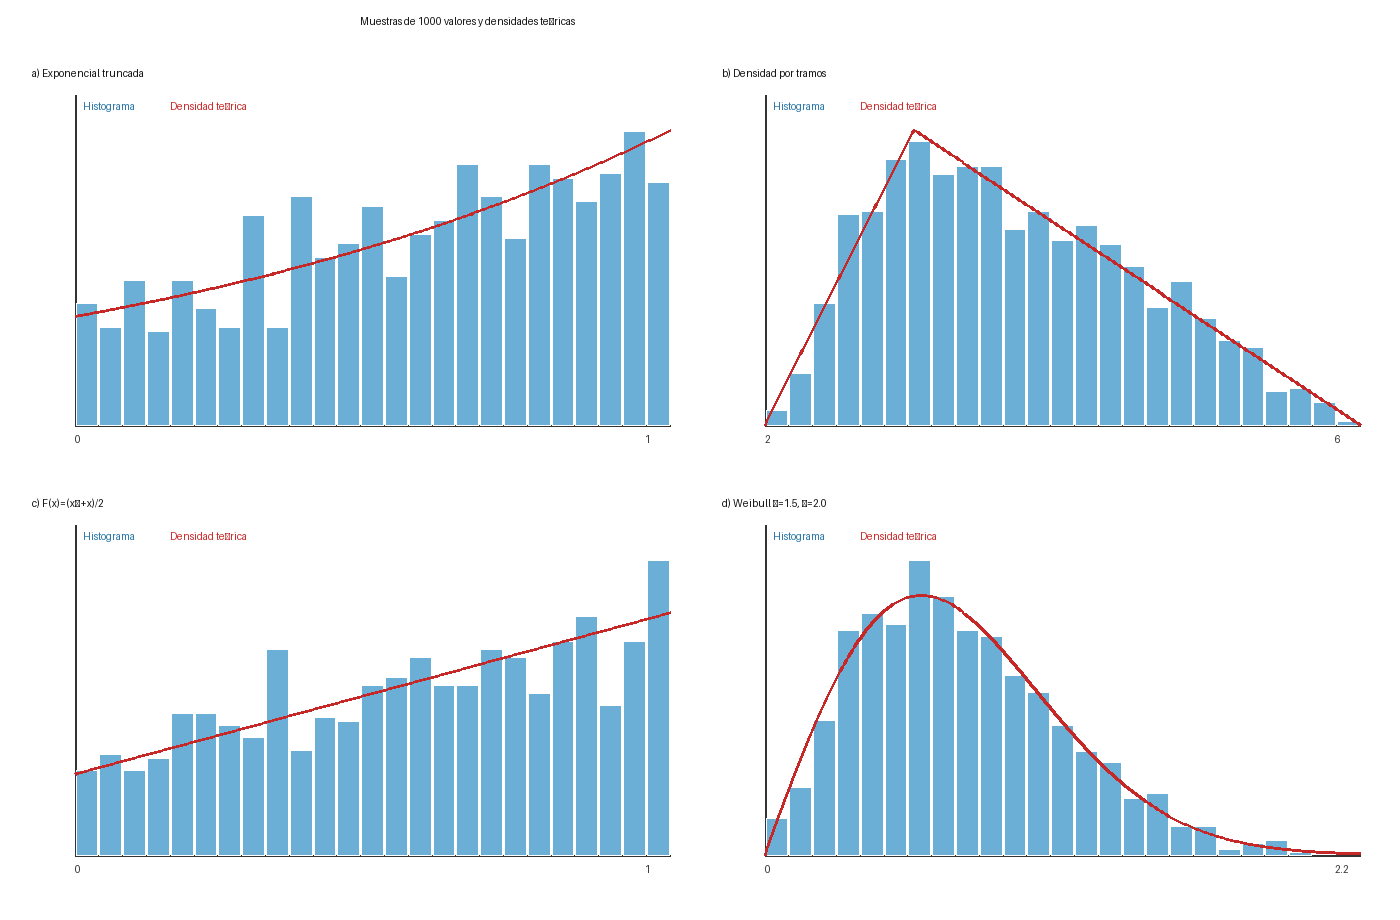

In [18]:
def fuente(tam=16, negrita=False):
    nombres = ['arialbd.ttf', 'DejaVuSans-Bold.ttf'] if negrita else ['arial.ttf', 'DejaVuSans.ttf']
    for nombre in nombres:
        try: return ImageFont.truetype(nombre, tam)
        except OSError: pass
    return ImageFont.load_default()

def panel_hist(draw, caja, datos, pdf, limites, titulo):
    x0, y0, x1, y1 = caja; margen = (55, 35, 20, 45)
    izq, sup, der, inf = x0+margen[0], y0+margen[1], x1-margen[2], y1-margen[3]
    hist, bordes = np.histogram(datos, bins=25, range=limites, density=True)
    gx = np.linspace(*limites, 300); gy = pdf(gx); ymax = max(hist.max(), gy.max())*1.12
    sx = lambda x: izq + (x-limites[0])/(limites[1]-limites[0])*(der-izq)
    sy = lambda y: inf - y/ymax*(inf-sup)
    draw.line((izq, sup, izq, inf, der, inf), fill='#333333', width=2)
    for h, a0, a1 in zip(hist, bordes[:-1], bordes[1:]):
        if h > 0:
            draw.rectangle((sx(a0)+1, sy(h), sx(a1)-1, inf), fill='#6baed6', outline='white')
    draw.line([(sx(x), sy(y)) for x, y in zip(gx, gy)], fill='#c62828', width=3)
    draw.text((x0+12, y0+7), titulo, font=fuente(16, True), fill='#111111')
    draw.text((izq, inf+8), f'{limites[0]:g}', font=fuente(12), fill='#333333')
    draw.text((der-25, inf+8), f'{limites[1]:g}', font=fuente(12), fill='#333333')
    draw.text((izq+8, sup+5), 'Histograma', font=fuente(12), fill='#2774a6')
    draw.text((izq+95, sup+5), 'Densidad teórica', font=fuente(12), fill='#c62828')

img = Image.new('RGB', (1400, 920), 'white'); draw = ImageDraw.Draw(img)
draw.text((360, 15), 'Muestras de 1000 valores y densidades teóricas', font=fuente(23, True), fill='#111111')
panel_hist(draw, (20,60,690,470), xa, lambda x: np.exp(x)/(math.e-1), (0,1), 'a) Exponencial truncada')
panel_hist(draw, (710,60,1380,470), xb, lambda x: np.where(x<=3,(x-2)/2,(2-x/3)/2), (2,6), 'b) Densidad por tramos')
panel_hist(draw, (20,490,690,900), xc, lambda x: (2*x+1)/2, (0,1), 'c) F(x)=(x²+x)/2')
lim_w = (0, max(2.2, float(xd.max())))
panel_hist(draw, (710,490,1380,900), xd, lambda x: alpha_w*beta_w*x**(beta_w-1)*np.exp(-alpha_w*x**beta_w), lim_w, f'd) Weibull α={alpha_w}, β={beta_w}')
display(img)

**Análisis.** Los histogramas reproducen la forma de las cuatro densidades: crecimiento exponencial en a, cambio de pendiente y cola decreciente en b, crecimiento lineal en c y forma unimodal de Weibull. Las medias empíricas cercanas a las teóricas sirven como comprobación adicional; las diferencias restantes son variación de Monte Carlo debida al tamaño finito de 1000 observaciones.

## 5.2. Procesos de Poisson y variable Coxian

Para el proceso homogéneo se generan tiempos entre llegadas exponenciales, $E=-\ln(U)/\lambda$, y se acumulan mientras el próximo evento no supere $T$. Se usan $T=10$ y $\lambda=2$.

Para la Coxian se usan cuatro etapas con tasas $[1.0,1.4,0.9,1.8]$ y probabilidades de continuar $[0.85,0.70,0.55]$. Tras completar cada etapa se decide si se continúa; la última siempre termina el trabajo.

In [19]:
def proceso_poisson(T, tasa, seed=505):
    if T <= 0 or tasa <= 0:
        raise ValueError('T y la tasa deben ser positivos.')
    rng, t, eventos = LCG(seed), 0.0, []
    while True:
        t += -math.log(rng.random()) / tasa
        if t > T:
            return np.array(eventos)
        eventos.append(t)

eventos_h = proceso_poisson(T=10, tasa=2)
print(f'Proceso homogéneo: {len(eventos_h)} eventos; valor esperado λT=20')
print('Tiempos:', np.round(eventos_h, 3))

Proceso homogéneo: 18 eventos; valor esperado λT=20
Tiempos: [0.42  1.659 1.916 2.426 2.451 3.218 5.243 5.85  6.297 6.558 6.595 6.878
 6.915 7.211 7.794 7.851 9.343 9.349]


In [20]:
def coxian(tasas, probabilidades_continuar, n=1, seed=606):
    tasas = np.asarray(tasas, dtype=float)
    alphas = np.asarray(probabilidades_continuar, dtype=float)
    if len(alphas) != len(tasas)-1 or np.any(tasas <= 0) or np.any((alphas < 0) | (alphas > 1)):
        raise ValueError('Se requieren k tasas positivas y k-1 probabilidades en [0,1].')
    rng, tiempos, etapas = LCG(seed), [], []
    for _ in range(n):
        total, completadas = 0.0, 0
        for i, tasa in enumerate(tasas):
            total += -math.log(rng.random()) / tasa
            completadas += 1
            if i < len(alphas) and rng.random() > alphas[i]:
                break
        tiempos.append(total); etapas.append(completadas)
    return np.array(tiempos), np.array(etapas)

tasas = [1.0, 1.4, 0.9, 1.8]
alphas = [0.85, 0.70, 0.55]
tiempos_c, etapas_c = coxian(tasas, alphas, n=1000)
media_cox_teorica = sum(np.prod(alphas[:i]) / tasas[i] for i in range(len(tasas)))
print(f'Coxian: media empírica={tiempos_c.mean():.4f}; media teórica={media_cox_teorica:.4f}')
valores, conteos = np.unique(etapas_c, return_counts=True)
print('Número de observaciones según última etapa alcanzada:', dict(zip(valores, conteos)))

Coxian: media empírica=2.4186; media teórica=2.4501
Número de observaciones según última etapa alcanzada: {np.int64(1): np.int64(151), np.int64(2): np.int64(274), np.int64(3): np.int64(260), np.int64(4): np.int64(315)}


## 5.3. Proceso de Poisson no homogéneo

La intensidad es $\lambda(t)=t/5$ para $0<t<5$ y $\lambda(t)=1+5(t-5)$ para $5\leq t<10$. En todo el intervalo está acotada por $M=26$. Se simula un proceso homogéneo candidato de tasa $M$ y se acepta cada evento en $t$ con probabilidad $\lambda(t)/M$. La intensidad integrada es $\Lambda(10)=2.5+67.5=70$, de modo que el número esperado de eventos es 70.

In [21]:
def intensidad(t):
    t = np.asarray(t, dtype=float)
    return np.where((t > 0) & (t < 5), t/5, np.where((t >= 5) & (t <= 10), 1 + 5*(t-5), 0.0))

def poisson_no_homogeneo(T=10, cota=26, seed=707):
    rng, t, aceptados, candidatos = LCG(seed), 0.0, [], 0
    while True:
        t += -math.log(rng.random()) / cota
        if t > T:
            return np.array(aceptados), candidatos
        candidatos += 1
        if rng.random() <= float(intensidad(t)) / cota:
            aceptados.append(t)

eventos_nh, candidatos = poisson_no_homogeneo()
print(f'Proceso no homogéneo: {len(eventos_nh)} eventos aceptados de {candidatos} candidatos')
print('Número esperado Λ(10)=70')
print('Primeros 15 tiempos:', np.round(eventos_nh[:15], 3))

Proceso no homogéneo: 68 eventos aceptados de 264 candidatos
Número esperado Λ(10)=70
Primeros 15 tiempos: [2.247 4.276 4.718 5.28  6.005 6.222 6.407 6.459 6.665 6.803 6.86  7.044
 7.08  7.121 7.196]


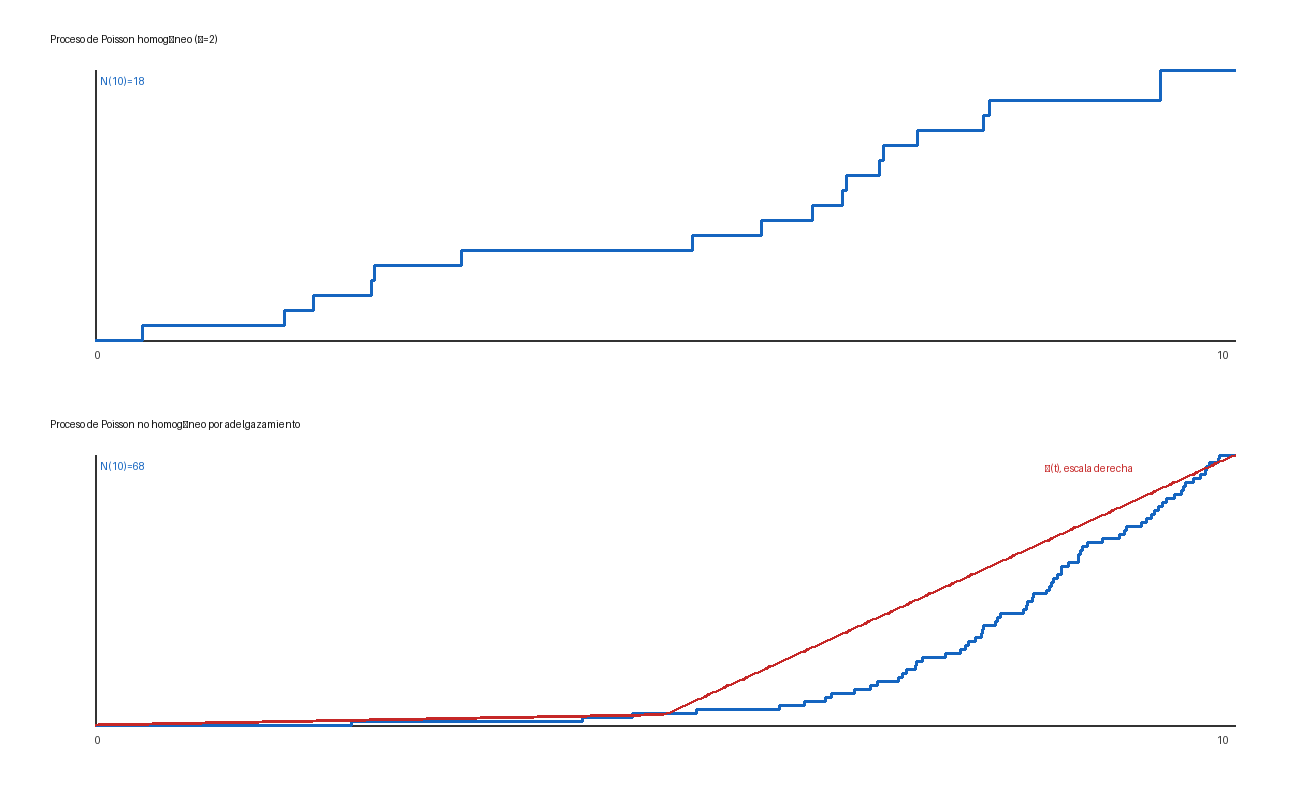

In [22]:
def panel_conteo(draw, caja, eventos, titulo, mostrar_intensidad=False):
    x0,y0,x1,y1=caja; izq,sup,der,inf=x0+65,y0+45,x1-35,y1-45
    ymax=max(len(eventos),1); sx=lambda t: izq+t/10*(der-izq); sy=lambda n: inf-n/ymax*(inf-sup)
    draw.line((izq,sup,izq,inf,der,inf), fill='#333333', width=2)
    tprev,nprev=0.0,0
    for t in eventos:
        draw.line((sx(tprev),sy(nprev),sx(t),sy(nprev)),fill='#1565c0',width=3)
        draw.line((sx(t),sy(nprev),sx(t),sy(nprev+1)),fill='#1565c0',width=3); tprev,nprev=t,nprev+1
    draw.line((sx(tprev),sy(nprev),sx(10),sy(nprev)),fill='#1565c0',width=3)
    if mostrar_intensidad:
        grid=np.linspace(0,10,300); vals=intensidad(grid)
        pts=[(sx(t), inf-float(v)/26*(inf-sup)) for t,v in zip(grid,vals)]
        draw.line(pts,fill='#c62828',width=3)
        draw.text((der-190,sup+7),'λ(t), escala derecha',font=fuente(13),fill='#c62828')
    draw.text((x0+20,y0+8),titulo,font=fuente(18,True),fill='#111111')
    draw.text((izq,inf+9),'0',font=fuente(12),fill='#333333'); draw.text((der-18,inf+9),'10',font=fuente(12),fill='#333333')
    draw.text((izq+5,sup+5),f'N(10)={len(eventos)}',font=fuente(13),fill='#1565c0')

img=Image.new('RGB',(1300,800),'white'); draw=ImageDraw.Draw(img)
panel_conteo(draw,(30,25,1270,385),eventos_h,'Proceso de Poisson homogéneo (λ=2)')
panel_conteo(draw,(30,410,1270,770),eventos_nh,'Proceso de Poisson no homogéneo por adelgazamiento',True)
display(img)